# 📊 今期・前期の売上構成比較

今期と前期の売上を商品カテゴリ別の積み上げ棒グラフで比較する。

> ※ 本notebookはローカルモジュール（`Lv01_03_configuration`）に依存しているため、単体での実行はできません。分析の流れとアウトプットの確認を目的としています。

In [ ]:
# ================================================ #
# imports
# ================================================ #

# 標準ライブラリ
import sys
from pathlib import Path

# 外部ライブラリ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from IPython.display import display

# ローカルモジュール
%load_ext autoreload
%autoreload 2
sys.path.insert(0, str(Path.cwd().parents[1]))
sys.path.insert(0, str(Path.cwd().parents[2]))
from Lv01_03_configuration.cnfg_b_dir_01_local import DIRS
from Lv01_03_configuration.cnfg_d_proc_01_merged import Proc01info, Cols, Items
from Lv01_03_configuration.cnfg_u_local_02_function import generate_dic_ym_to_fiscal_quarter
from Lv01_03_configuration.cnfg_p_chart import generate_chart_category_sales_comparison
from Lv01_03_configuration.cnfg_a_api_01_pub import (
    pmod_01_loading_df as func_loading_df,
    pmod_20_formatting_datetime as func_datetime_format,
)

In [2]:
# ================================================ #
# データ読み込み・加工
# ================================================ #

# データ読み込み
df = func_loading_df.read_as_dataframe_from_excel_or_csv(
    target_file_path=Path(DIRS.Processed) / Proc01info.FILENAME
)

# 年月カラムの追加
df = (
    df.copy()
    .pipe(
        func_datetime_format.format_ss_half_y4m2,
        target_col        = Cols.order_date,
        output_col        = Cols.order_ym,
        trans_to_datetime = True
    )
)

# 集計期間の設定
fiscal_start_month = 1
start_year         = 2025
start_month        = 1
end_year           = start_year
end_month          = 12

# 今期・前期の年月リスト生成
dic_current_quarter = generate_dic_ym_to_fiscal_quarter(
    fiscal_start_month = fiscal_start_month,
    start_year         = start_year,
    start_month        = start_month,
    end_year           = end_year,
    end_month          = end_month
)
dic_previous_quarter = generate_dic_ym_to_fiscal_quarter(
    fiscal_start_month = fiscal_start_month,
    start_year         = start_year - 1,
    start_month        = start_month,
    end_year           = end_year - 1,
    end_month          = end_month
)

current_list  = list(dic_current_quarter)[:7]
previous_list = list(dic_previous_quarter)

# 年次ラベルの付与
dic_extract = {
    **{s: "今年" for s in current_list},
    **{s: "去年" for s in previous_list},
}

df_sample = df.copy()
df_sample = df_sample[df_sample[Cols.order_ym].isin(list(dic_extract))]
df_sample["annnual_type"] = df_sample[Cols.order_ym].map(dic_extract).fillna("NoDate")

# ピボット集計
x_axis_col       = "annnual_type"
x_axis_item_list = ["去年", "今年"]
y_axis_col       = Cols.category
y_axis_item_list = Items.list_product_category
color_map        = Items.light_color_map_procat()

df_pivot = df_sample.pivot_table(
    index      = x_axis_col,
    columns    = y_axis_col,
    values     = Cols.sales,
    aggfunc    = "sum",
    fill_value = 0
)
df_pivot = df_pivot.reindex(
    index      = x_axis_item_list,
    columns    = y_axis_item_list,
    fill_value = 0
)

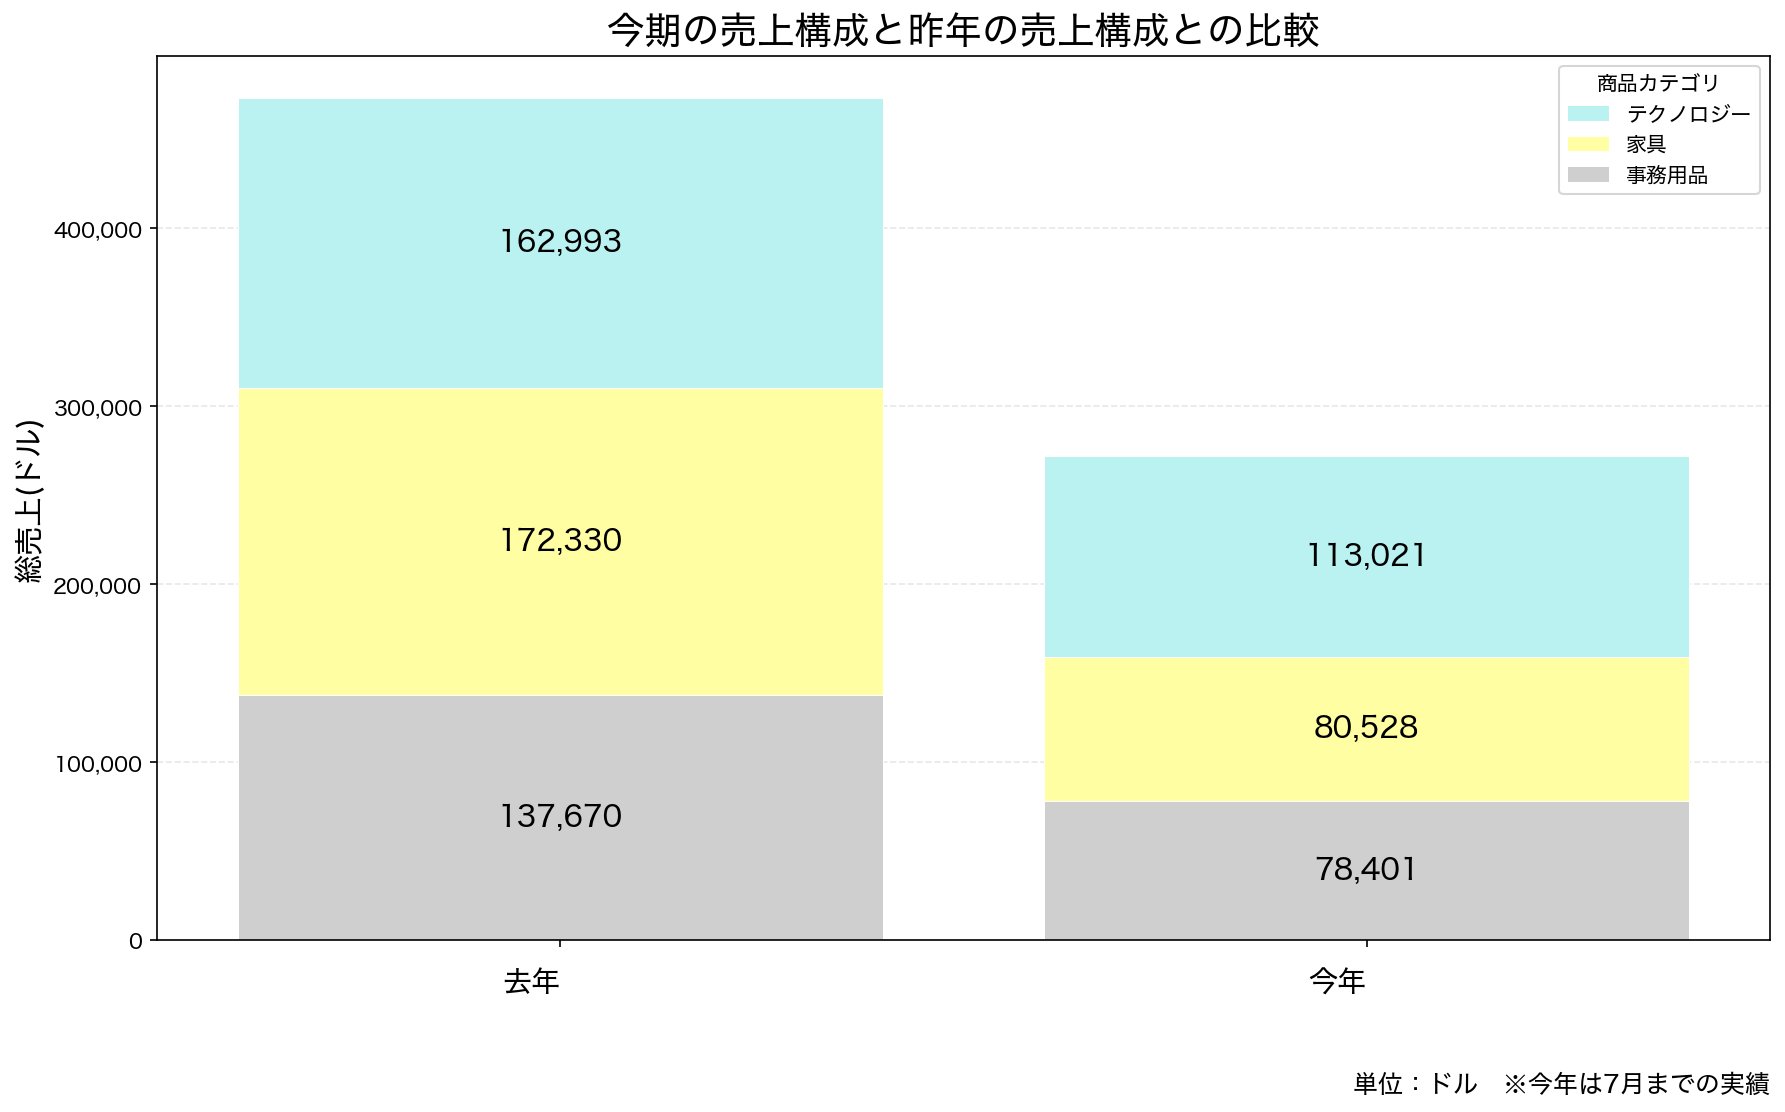

In [4]:
# ================================================ #
# チャート生成
# ================================================ #

plt.rcParams['font.family'] = 'Hiragino Sans'
fig, ax = plt.subplots(figsize=(12, 7.5), dpi=150)

generate_chart_category_sales_comparison(
    df_pivot         = df_pivot,
    ax               = ax,
    x_axis_item_list = x_axis_item_list,
    y_axis_item_list = y_axis_item_list,
    color_map        = color_map,
    title            = "今期の売上構成と昨年の売上構成との比較",
    ylabel           = "総売上(ドル)",
    note             = "単位：ドル　※今年は7月までの実績",
)

plt.tight_layout()
plt.show()